# Heart Disease Risk Classifier — Phase 2 & 3: Preprocessing + Modelling
 Cleveland Heart Disease Dataset

In [1]:
# importing necessary libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, GridSearchCV)
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score)
import warnings
warnings.filterwarnings("ignore")

In [2]:
# load and clean data same procedure as EDA
# ════════════════════════════════════════════════════════════════════════════
 
COL_NAMES = ["age", "sex", "cp", "trestbps", "chol", "fbs",
             "restecg", "thalach", "exang", "oldpeak",
             "slope", "ca", "thal", "target"]
 
try:
    df = pd.read_csv("heart.csv")
    if df.shape[1] != 14:
        raise ValueError
except Exception:
    df = pd.read_csv("heart.csv", header=None, names=COL_NAMES)
 
df.replace("?", np.nan, inplace=True)
df["ca"]   = pd.to_numeric(df["ca"],   errors="coerce")
df["thal"] = pd.to_numeric(df["thal"], errors="coerce")
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
 
if df["target"].max() > 1:
    df["target"] = (df["target"] > 0).astype(int)
 
X = df.drop(columns=["target"])
y = df["target"]
 
print(f"Dataset ready: {X.shape[0]} rows × {X.shape[1]} features")
print(f"Class balance: {y.value_counts().to_dict()}")

Dataset ready: 303 rows × 13 features
Class balance: {0: 164, 1: 139}


In [4]:
# PREPROCESSING PIPELINE

 
# Feature groups
# Categorical: cp (chest pain), restecg, slope, thal — no meaningful order
# Binary:      sex, fbs, exang — already 0/1, no encoding needed
# Numerical:   everything else — scale to zero mean, unit variance
 
CATEGORICAL = ["cp", "restecg", "slope", "thal"]
NUMERICAL   = ["age", "trestbps", "chol", "thalach",
               "oldpeak", "ca", "sex", "fbs", "exang"]

SEED = 42
 
# Numerical: impute, then scale
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
 
# Categorical: impute with mode then one-hot encode
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
 
preprocessor = ColumnTransformer([
    ("num", num_pipe, NUMERICAL),
    ("cat", cat_pipe, CATEGORICAL),
])
 
# Quick check — transform and inspect shape
X_check = preprocessor.fit_transform(X)
print(f"\nAfter preprocessing: {X_check.shape[1]} features "
      f"(9 numerical + {X_check.shape[1]-9} one-hot encoded)")
 
# Train / test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test  class balance: {y_test.value_counts().to_dict()}")


After preprocessing: 22 features (9 numerical + 13 one-hot encoded)

Train: 242  |  Test: 61
Train class balance: {0: 131, 1: 111}
Test  class balance: {0: 33, 1: 28}


# DEFINING MODELS

Selecting differenct classifier models to pick the best fit

In [5]:
models = {
    "Logistic Regression": Pipeline([
        ("pre",   preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),
    "KNN": Pipeline([
        ("pre",   preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "Decision Tree": Pipeline([
        ("pre",   preprocessor),
        ("model", DecisionTreeClassifier(max_depth=4, random_state=SEED)),
    ]),
    "Random Forest": Pipeline([
        ("pre",   preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, random_state=SEED)),
    ]),
    "SVM": Pipeline([
        ("pre",   preprocessor),
        ("model", SVC(kernel="rbf", probability=True, random_state=SEED)),
    ]),
}

# STRATIFIED K-FOLD CROSS-VALIDATION

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
 
SCORING = ["accuracy", "f1", "precision", "recall", "roc_auc"]
 
results = {}
print("\nRunning 5-fold stratified cross-validation...\n")
 
for name, pipe in models.items():
    cv_results = cross_validate(pipe, X_train, y_train,
                                cv=cv, scoring=SCORING,
                                return_train_score=False)
    results[name] = {
        "Accuracy"  : cv_results["test_accuracy"].mean(),
        "F1"        : cv_results["test_f1"].mean(),
        "Precision" : cv_results["test_precision"].mean(),
        "Recall"    : cv_results["test_recall"].mean(),
        "AUC-ROC"   : cv_results["test_roc_auc"].mean(),
        "F1 Std"    : cv_results["test_f1"].std(),
    }
    print(f"  {name:<22} Acc={results[name]['Accuracy']:.3f}  "
          f"F1={results[name]['F1']:.3f}  "
          f"AUC={results[name]['AUC-ROC']:.3f}  "
          f"Recall={results[name]['Recall']:.3f}")


Running 5-fold stratified cross-validation...

  Logistic Regression    Acc=0.843  F1=0.822  AUC=0.907  Recall=0.792
  KNN                    Acc=0.801  F1=0.780  AUC=0.863  Recall=0.765
  Decision Tree          Acc=0.731  F1=0.695  AUC=0.790  Recall=0.674
  Random Forest          Acc=0.814  F1=0.789  AUC=0.893  Recall=0.765
  SVM                    Acc=0.818  F1=0.791  AUC=0.887  Recall=0.756


In [7]:
# Comparing Models 
 
results_df = (pd.DataFrame(results).T
                .sort_values("AUC-ROC", ascending=False)
                .round(4))
 
print("\n" + "=" * 70)
print("MODEL COMPARISON  (sorted by AUC-ROC, 5-fold CV on training set)")
print("=" * 70)
print(results_df.drop(columns=["F1 Std"]).to_string())
 
best_name = results_df.index[0]
print(f"\n✓ Best model: {best_name}")


MODEL COMPARISON  (sorted by AUC-ROC, 5-fold CV on training set)
                     Accuracy      F1  Precision  Recall  AUC-ROC
Logistic Regression    0.8429  0.8223     0.8589  0.7925   0.9065
Random Forest          0.8139  0.7893     0.8264  0.7648   0.8926
SVM                    0.8180  0.7908     0.8378  0.7561   0.8866
KNN                    0.8014  0.7798     0.7969  0.7652   0.8628
Decision Tree          0.7315  0.6955     0.7242  0.6743   0.7903

✓ Best model: Logistic Regression


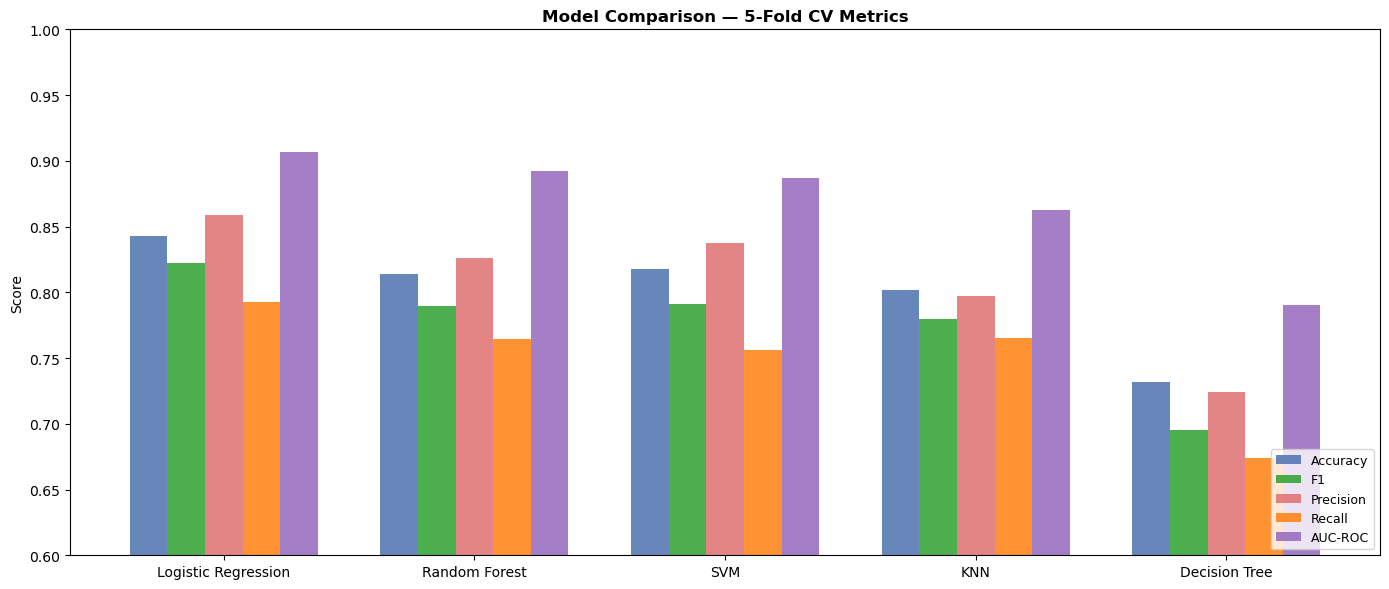

In [8]:
# COMPARISON BY BAR CHART
 
metrics   = ["Accuracy", "F1", "Precision", "Recall", "AUC-ROC"]
model_names = results_df.index.tolist()
x = np.arange(len(model_names))
width = 0.15
 
fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#4C72B0", "#2ca02c", "#E07070", "#FF7F0E", "#9467BD"]
 
for i, metric in enumerate(metrics):
    vals = results_df[metric].values
    bars = ax.bar(x + i * width, vals, width, label=metric,
                  color=colors[i], alpha=0.85)
 
ax.set_xticks(x + width * 2)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0.6, 1.0)
ax.set_title("Model Comparison — 5-Fold CV Metrics", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("phase2_3_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# BONUS — KNN: FIND OPTIMAL K


KNN optimal k: 17  (CV F1=0.7984)


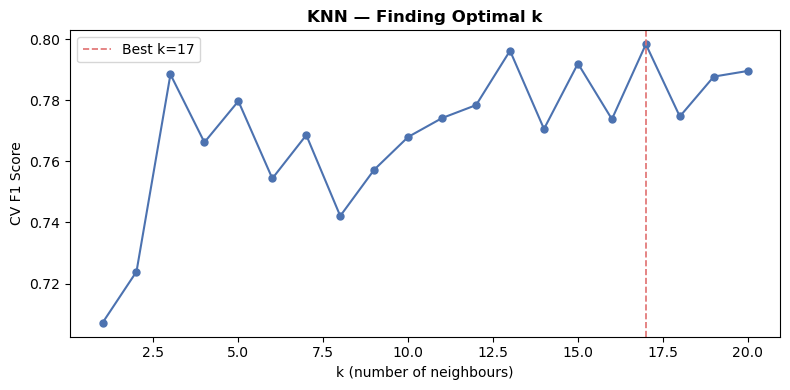

In [9]:
k_range = range(1, 21)
k_scores = []
 
for k in k_range:
    knn_pipe = Pipeline([
        ("pre",   preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=k)),
    ])
    score = cross_validate(knn_pipe, X_train, y_train,
                           cv=cv, scoring=["f1"])["test_f1"].mean()
    k_scores.append(score)
 
best_k = k_range[np.argmax(k_scores)]
print(f"\nKNN optimal k: {best_k}  (CV F1={max(k_scores):.4f})")
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), k_scores, marker="o", color="#4C72B0",
        linewidth=1.5, markersize=5)
ax.axvline(best_k, color="#E07070", linestyle="--",
           linewidth=1.2, label=f"Best k={best_k}")
ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("CV F1 Score")
ax.set_title("KNN — Finding Optimal k", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("phase2_3_knn_k_search.png", dpi=150, bbox_inches="tight")
plt.show()

# BONUS — DECISION TREE VISUALISATION

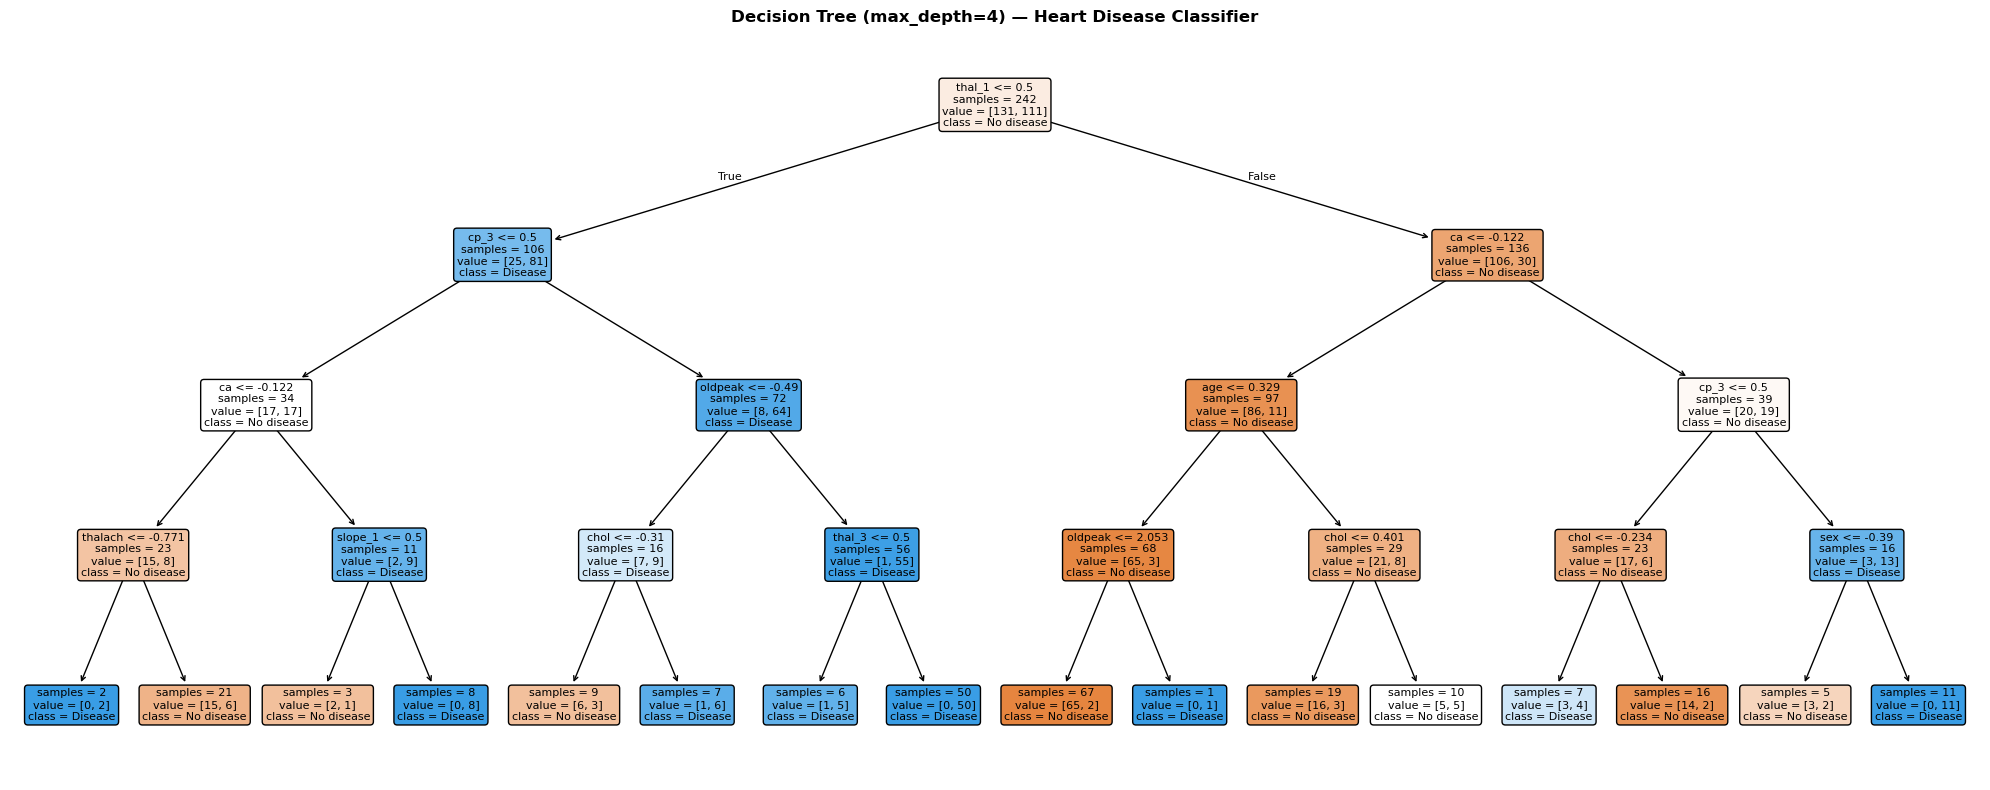


Saved:
  phase2_3_model_comparison.png
  phase2_3_knn_k_search.png
  phase2_3_decision_tree.png

Next: Phase 4 — Confusion matrices, ROC/PR curves, threshold tuning


In [10]:
# Fit DT pipeline to get the tree
dt_pipe = models["Decision Tree"]
dt_pipe.fit(X_train, y_train)
dt_model = dt_pipe.named_steps["model"]
 
# Feature names after preprocessing
ohe_cats = (dt_pipe.named_steps["pre"]
              .named_transformers_["cat"]
              .named_steps["encoder"]
              .get_feature_names_out(CATEGORICAL)
              .tolist())
feature_names = NUMERICAL + ohe_cats
 
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_model, feature_names=feature_names,
          class_names=["No disease", "Disease"],
          filled=True, rounded=True, fontsize=8, ax=ax,
          impurity=False, proportion=False)
ax.set_title("Decision Tree (max_depth=4) — Heart Disease Classifier",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("phase2_3_decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\nSaved:")
print("  phase2_3_model_comparison.png")
print("  phase2_3_knn_k_search.png")
print("  phase2_3_decision_tree.png")
print("\nNext: Phase 4 — Confusion matrices, ROC/PR curves, threshold tuning")